In [76]:
from ultralytics import YOLO
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import random

In [77]:
# ---------- bbox helpers ----------

def calculate_iou(box1, box2):
    """box format: [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    a2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0


def yolo_to_xyxy(yolo_box, img_width, img_height):
    """YOLO 歸一化 [cx, cy, w, h] -> [x1, y1, x2, y2]"""
    cx, cy, w, h = yolo_box
    return [
        (cx - w / 2) * img_width,
        (cy - h / 2) * img_height,
        (cx + w / 2) * img_width,
        (cy + h / 2) * img_height,
    ]


def box_center(box):
    return np.array([(box[0] + box[2]) / 2, (box[1] + box[3]) / 2])


def greedy_nms(boxes, scores, iou_threshold):
    """Greedy NMS. Returns indices of kept boxes."""
    if not boxes:
        return []
    boxes  = np.array(boxes)
    scores = np.array(scores)
    order  = scores.argsort()[::-1]
    kept, suppressed = [], set()
    for i in [int(x) for x in order]:
        if i in suppressed:
            continue
        kept.append(i)
        for j in [int(x) for x in order]:
            if j == i or j in suppressed:
                continue
            if calculate_iou(boxes[i], boxes[j]) >= iou_threshold:
                suppressed.add(j)
    return kept


# ---------- GT loading ----------

def load_gt_boxes(od_image_path, img_width, img_height):
    """Load GT bounding boxes from OD-format label file."""
    label_path = (
        od_image_path
        .replace('/images/', '/labels/')
        .replace('.png', '.txt')
        .replace('.jpg', '.txt')
    )
    gt_nodule, gt_maybe = [], []
    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                class_id = int(float(parts[0]))
                xyxy = yolo_to_xyxy(list(map(float, parts[1:5])), img_width, img_height)
                if class_id == 0:
                    gt_nodule.append(xyxy)
                elif class_id == 1:
                    gt_maybe.append(xyxy)
    return gt_nodule, gt_maybe


# ---------- extract predictions ----------

def extract_nodule_preds(result):
    """Extract class-0 predictions as list of {'box', 'conf'}."""
    preds = []
    if result.boxes is not None and len(result.boxes) > 0:
        cls_arr  = result.boxes.cls.cpu().numpy()
        xyxy_arr = result.boxes.xyxy.cpu().numpy()
        conf_arr = result.boxes.conf.cpu().numpy()
        for i, cls in enumerate(cls_arr):
            if int(cls) == 0:
                preds.append({'box': xyxy_arr[i].tolist(), 'conf': float(conf_arr[i])})
    return preds

In [78]:
def fuse_predictions(od_result, seg_result, strategy='or', nms_iou=0.5):
    """
    Fuse predictions from OD and Seg models.

    strategy:
      'or'  - 聯集: 兩個模型的預測框全部合併，再做 greedy NMS
      'and' - 交集: 只保留兩個模型都同意的框（IoU >= nms_iou），
               框取平均座標，conf 取平均

    Returns list of {'box': [x1,y1,x2,y2], 'conf': float, 'source': str}
    """
    od_preds  = extract_nodule_preds(od_result)
    seg_preds = extract_nodule_preds(seg_result)

    if strategy == 'or':
        all_boxes = [p['box']  for p in od_preds + seg_preds]
        all_confs = [p['conf'] for p in od_preds + seg_preds]
        all_srcs  = ['od'] * len(od_preds) + ['seg'] * len(seg_preds)
        if not all_boxes:
            return []
        kept = greedy_nms(all_boxes, all_confs, nms_iou)
        return [{'box': all_boxes[k], 'conf': all_confs[k], 'source': all_srcs[k]}
                for k in kept]

    elif strategy == 'and':
        fused = []
        matched_seg = set()
        for i, op in enumerate(od_preds):
            best_iou, best_j = 0, -1
            for j, sp in enumerate(seg_preds):
                if j in matched_seg:
                    continue
                iou = calculate_iou(op['box'], sp['box'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= nms_iou:
                matched_seg.add(best_j)
                sp = seg_preds[best_j]
                avg_conf   = (op['conf'] + sp['conf']) / 2
                merged_box = [(op['box'][k] + sp['box'][k]) / 2 for k in range(4)]
                fused.append({'box': merged_box, 'conf': avg_conf, 'source': 'both'})
        return fused

    else:
        raise ValueError(f"Unknown strategy: '{strategy}'. Use 'or' or 'and'.")

In [79]:
def match_and_build_records(pred_entries, gt_nodule, gt_maybe,
                             patient_id, file_name, iou_threshold):
    """
    pred_entries : list of {'box': [x1,y1,x2,y2], 'conf': float}
    Returns list of record dicts (TP / FP / FN / TN).
    """
    matched_gt   = set()
    matched_pred = set()
    ignored_pred = set()
    matched_pairs = []

    for i, pred in enumerate(pred_entries):
        best_iou, best_j = 0, -1
        for j, gt_box in enumerate(gt_nodule):
            if j in matched_gt:
                continue
            iou = calculate_iou(pred['box'], gt_box)
            if iou > best_iou:
                best_iou, best_j = iou, j

        if best_iou >= iou_threshold:
            matched_gt.add(best_j)
            matched_pred.add(i)
            matched_pairs.append((i, best_j, best_iou))
        else:
            maybe_iou = max(
                (calculate_iou(pred['box'], gb) for gb in gt_maybe), default=0
            )
            if maybe_iou >= iou_threshold:
                ignored_pred.add(i)

    records = []
    base = {'patient_ID': patient_id, 'file_name': file_name}

    for pred_i, gt_j, iou in matched_pairs:
        pb, gb = pred_entries[pred_i]['box'], gt_nodule[gt_j]
        records.append({**base,
            'match_type': 'TP', 'pred_box': pb, 'gt_box': gb,
            'iou': iou,
            'conf': pred_entries[pred_i]['conf'],
            'center_distance': float(np.linalg.norm(box_center(pb) - box_center(gb))),
            'source': pred_entries[pred_i].get('source', ''),
        })

    for i, pred in enumerate(pred_entries):
        if i not in matched_pred and i not in ignored_pred:
            records.append({**base,
                'match_type': 'FP', 'pred_box': pred['box'], 'gt_box': None,
                'iou': 0.0, 'conf': pred['conf'], 'center_distance': None,
                'source': pred.get('source', ''),
            })

    for j, gb in enumerate(gt_nodule):
        if j not in matched_gt:
            records.append({**base,
                'match_type': 'FN', 'pred_box': None, 'gt_box': gb,
                'iou': 0.0, 'conf': None, 'center_distance': None, 'source': None,
            })

    if not records:
        records.append({**base,
            'match_type': 'TN',
            'pred_box': None, 'gt_box': None,
            'iou': None, 'conf': None, 'center_distance': None, 'source': None,
        })
    return records


def get_records(od_result, seg_result, od_image_path,
                strategy, patient_id, iou_threshold, nms_iou):
    """
    strategy: 'od_only' | 'seg_only' | 'or' | 'and'
    GT is always loaded from OD-format label (bbox).
    """
    img_height, img_width = od_result.orig_shape
    gt_nodule, gt_maybe  = load_gt_boxes(od_image_path, img_width, img_height)
    file_name = Path(od_image_path).name

    if strategy == 'od_only':
        preds = extract_nodule_preds(od_result)
    elif strategy == 'seg_only':
        preds = extract_nodule_preds(seg_result)
    else:  # 'or' / 'and'
        preds = fuse_predictions(od_result, seg_result,
                                  strategy=strategy, nms_iou=nms_iou)

    return match_and_build_records(preds, gt_nodule, gt_maybe,
                                    patient_id, file_name, iou_threshold)

In [80]:
def compute_metrics_from_counts(tp, fp, fn):
    eta = 1e-9
    recall    = tp / (tp + fn + eta)
    precision = tp / (tp + fp + eta)
    f1        = 2 * precision * recall / (precision + recall + eta)
    return recall, precision, f1


def get_image_metrics(df):
    counts = (
        df[df['match_type'].isin(['TP', 'FP', 'FN'])]
        .groupby(['file_name', 'match_type']).size().unstack(fill_value=0)
    )
    for col in ['TP', 'FP', 'FN']:
        if col not in counts:
            counts[col] = 0
    counts[['recall', 'precision', 'f1']] = [
        compute_metrics_from_counts(r.TP, r.FP, r.FN) for _, r in counts.iterrows()
    ]
    return counts


def get_patient_metrics(df):
    counts = (
        df[df['match_type'].isin(['TP', 'FP', 'FN'])]
        .groupby(['patient_ID', 'match_type']).size().unstack(fill_value=0)
    )
    for col in ['TP', 'FP', 'FN']:
        if col not in counts:
            counts[col] = 0
    counts[['recall', 'precision', 'f1']] = [
        compute_metrics_from_counts(r.TP, r.FP, r.FN) for _, r in counts.iterrows()
    ]
    return counts


def summarize(df, label=''):
    img_df = get_image_metrics(df)
    pat_df = get_patient_metrics(df)
    tag = f"[{label}] " if label else "  "
    print(f"{tag}Image-wise   | recall={img_df['recall'].mean():.4f}  "
          f"precision={img_df['precision'].mean():.4f}  F1={img_df['f1'].mean():.4f}")
    print(f"{tag}Patient-wise | recall={pat_df['recall'].mean():.4f}  "
          f"precision={pat_df['precision'].mean():.4f}  F1={pat_df['f1'].mean():.4f}")
    tp_iou = df.loc[df['match_type'] == 'TP', 'iou'].dropna()
    if len(tp_iou):
        print(f"{tag}TP IoU       | n={len(tp_iou)}  mean={tp_iou.mean():.4f}  "
              f"median={tp_iou.median():.4f}  std={tp_iou.std():.4f}")
    tp_cd = df.loc[df['match_type'] == 'TP', 'center_distance'].dropna()
    if len(tp_cd):
        print(f"{tag}Center dist  | n={len(tp_cd)}  mean={tp_cd.mean():.2f}  "
              f"median={tp_cd.median():.2f}  max={tp_cd.max():.2f}")
    return img_df, pat_df


def calculate_ap(df):
    """101-point interpolated AP (COCO style)."""
    total_gt = df['match_type'].isin(['TP', 'FN']).sum()
    if total_gt == 0:
        return 0.0, np.array([]), np.array([])
    preds = (
        df[df['match_type'].isin(['TP', 'FP'])].dropna(subset=['conf'])
        .sort_values('conf', ascending=False).reset_index(drop=True)
    )
    if len(preds) == 0:
        return 0.0, np.array([0.0]), np.array([0.0])
    tp_cs = (preds['match_type'] == 'TP').cumsum().values
    fp_cs = (preds['match_type'] == 'FP').cumsum().values
    recalls    = tp_cs / total_gt
    precisions = tp_cs / (tp_cs + fp_cs)
    ap = 0.0
    for thr in np.linspace(0, 1, 101):
        p = precisions[recalls >= thr]
        ap += p.max() if len(p) > 0 else 0.0
    return ap / 101, recalls, precisions

In [81]:
data_root = "/Users/tony.tu/Desktop/戴承智慧/thyroid"

In [82]:
od_name  = "2026_03_11(1)"
seg_name = "2026_03_12(1)"

od_model  = YOLO(f'{data_root}/yolo_output/runs/detect/{od_name}/weights/best.pt')
seg_model = YOLO(f'{data_root}/yolo_output/runs/seg/{seg_name}/weights/best.pt')

print(f"OD  model: {od_name}")
print(f"Seg model: {seg_name}")

OD  model: 2026_03_11(1)
Seg model: 2026_03_12(1)


In [83]:
data_df = pd.read_csv(f'{data_root}/yolo_data/all_csv_files/combined_dataset_info_v5.csv')

val_df = data_df[
    (data_df['dataset'] == 'CG') &
    (data_df['train_or_test'] == 'test') &
    (data_df['nodule_type'] != 'none')
]

od_root  = f'{data_root}/yolo_data/all_data_nodule_normal_cut_od/images'
seg_root = f'{data_root}/yolo_data/all_data_nodule_normal_cut_seg/images'

od_file_list  = [os.path.join(od_root,  f"{fn}.png") for fn in val_df['file_name']]
seg_file_list = [os.path.join(seg_root, f"{fn}.png") for fn in val_df['file_name']]
pid_list      = val_df['patient_ID'].tolist()

print(f"Total images: {len(od_file_list)}")

Total images: 1444


In [84]:

# od_root  = f'{data_root}/yolo_data/ThyroidXL_data/test_od/images'
# seg_root = f'{data_root}/yolo_data/ThyroidXL_data/test_seg/images'
# image_name_od_dir = os.listdir(od_root)
# image_name_seg_dir = os.listdir(seg_root)


# od_file_list  = [os.path.join(od_root,  f"{fn}") for fn in image_name_od_dir]
# seg_file_list = [os.path.join(seg_root, f"{fn}") for fn in image_name_seg_dir]
# pid_list      = [f"{fn.split("_")[0]}" for fn in image_name_od_dir]

# print(f"Total images: {len(od_file_list)}")

In [85]:
import torch

device         = "mps"
conf_threshold = 0.5
batch_size     = 32

print(f"Using device: {device}")

# --- OD inference ---
od_raw = []   # (od_image_path, pid, od_result)
for i in tqdm(range(0, len(od_file_list), batch_size), desc="OD  Inference"):
    batch_paths = od_file_list[i:i + batch_size]
    batch_pids  = pid_list[i:i + batch_size]
    for path, pid, res in zip(
        batch_paths, batch_pids,
        od_model(batch_paths, conf=conf_threshold, verbose=False, device=device)
    ):
        od_raw.append((path, pid, res))

# --- Seg inference ---
seg_raw = []  # (seg_image_path, pid, seg_result)
for i in tqdm(range(0, len(seg_file_list), batch_size), desc="Seg Inference"):
    batch_paths = seg_file_list[i:i + batch_size]
    batch_pids  = pid_list[i:i + batch_size]
    for path, pid, res in zip(
        batch_paths, batch_pids,
        seg_model(batch_paths, conf=conf_threshold, verbose=False, device=device)
    ):
        seg_raw.append((path, pid, res))

print(f"OD  inference done: {len(od_raw)} images")
print(f"Seg inference done: {len(seg_raw)} images")

Using device: mps


Seg Inference: 100%|██████████| 46/46 [00:41<00:00,  1.12it/s]

OD  inference done: 1444 images
Seg inference done: 1444 images


In [86]:
# --- 評估設定 ---
strategies            = ['od_only', 'seg_only', 'or', 'and']
nms_iou               = 0.5   # 融合時 NMS / AND 判斷用的 IoU 門檻
iou_thresholds_report = [0.3, 0.5, 0.7]
iou_thresholds_map    = list(np.round(np.arange(0.5, 1.0, 0.05), 2))
all_iou_thresholds    = sorted(set(iou_thresholds_report + iou_thresholds_map))

# results_by_strategy_iou[strategy][iou_threshold] = DataFrame
results_by_strategy_iou = {s: {} for s in strategies}

for iou_threshold in tqdm(all_iou_thresholds, desc="Matching"):
    for strategy in strategies:
        all_records = []
        for (od_path, pid, od_res), (_, _, seg_res) in zip(od_raw, seg_raw):
            records = get_records(
                od_res, seg_res, od_path,
                strategy=strategy,
                patient_id=pid,
                iou_threshold=iou_threshold,
                nms_iou=nms_iou,
            )
            all_records.extend(records)
        results_by_strategy_iou[strategy][iou_threshold] = pd.DataFrame(all_records)

# --- 印出 report thresholds ---
strategy_labels = {
    'od_only':  'OD only',
    'seg_only': 'Seg only (bbox)',
    'or':       'Fusion OR (union)',
    'and':      'Fusion AND (intersection)',
}

for iou_threshold in iou_thresholds_report:
    print(f"\n{'='*60}")
    print(f"IoU threshold = {iou_threshold}")
    print('='*60)
    for strategy in strategies:
        print(f"  --- {strategy_labels[strategy]} ---")
        summarize(results_by_strategy_iou[strategy][iou_threshold])

Matching: 100%|██████████| 11/11 [00:50<00:00,  4.62s/it]



IoU threshold = 0.3
  --- OD only ---
  Image-wise   | recall=0.9210  precision=0.9439  F1=0.9267
  Patient-wise | recall=0.9147  precision=0.9695  F1=0.9354
  TP IoU       | n=1402  mean=0.8613  median=0.8828  std=0.0927
  Center dist  | n=1402  mean=3.72  median=2.35  max=91.38
  --- Seg only (bbox) ---
  Image-wise   | recall=0.9178  precision=0.9442  F1=0.9247
  Patient-wise | recall=0.9092  precision=0.9660  F1=0.9302
  TP IoU       | n=1394  mean=0.8593  median=0.8810  std=0.0911
  Center dist  | n=1394  mean=3.86  median=2.33  max=92.99
  --- Fusion OR (union) ---
  Image-wise   | recall=0.9436  precision=0.9635  F1=0.9477
  Patient-wise | recall=0.9380  precision=0.9739  F1=0.9512
  TP IoU       | n=1440  mean=0.8591  median=0.8823  std=0.0934
  Center dist  | n=1440  mean=3.80  median=2.34  max=91.38
  --- Fusion AND (intersection) ---
  Image-wise   | recall=0.8941  precision=0.9258  F1=0.9043
  Patient-wise | recall=0.8851  precision=0.9677  F1=0.9160
  TP IoU       | n=135

In [87]:
rows = []

for strategy in strategies:
    # mAP@[0.5:0.95]
    aps_map = [calculate_ap(results_by_strategy_iou[strategy][iou])[0]
               for iou in iou_thresholds_map]
    mAP = float(np.mean(aps_map))

    for iou_threshold in iou_thresholds_report:
        ndf = results_by_strategy_iou[strategy][iou_threshold]

        ap, _, _ = calculate_ap(ndf)

        img_df = get_image_metrics(ndf)
        pat_df = get_patient_metrics(ndf)

        tp_iou = ndf.loc[ndf['match_type'] == 'TP', 'iou'].dropna()
        tp_cd  = ndf.loc[ndf['match_type'] == 'TP', 'center_distance'].dropna()

        rows.append({
            'strategy':          strategy_labels[strategy],
            'iou_threshold':     iou_threshold,
            'AP':                round(ap, 4),
            'mAP@0.5:0.95':     round(mAP, 4),
            'img_recall':        round(img_df['recall'].mean(),    4),
            'img_precision':     round(img_df['precision'].mean(), 4),
            'img_f1':            round(img_df['f1'].mean(),        4),
            'pat_recall':        round(pat_df['recall'].mean(),    4),
            'pat_precision':     round(pat_df['precision'].mean(), 4),
            'pat_f1':            round(pat_df['f1'].mean(),        4),
            'iou_mean':          round(tp_iou.mean(),   4) if len(tp_iou) > 0 else None,
            'iou_median':        round(tp_iou.median(), 4) if len(tp_iou) > 0 else None,
            'cd_mean':           round(tp_cd.mean(),    2) if len(tp_cd)  > 0 else None,
            'cd_median':         round(tp_cd.median(),  2) if len(tp_cd)  > 0 else None,
            'cd_max':            round(tp_cd.max(),     2) if len(tp_cd)  > 0 else None,
        })

summary_df = pd.DataFrame(rows).set_index(['strategy', 'iou_threshold'])
display(summary_df)

AP  mAP@0.5:0.95  img_recall  \
strategy                  iou_threshold                                     
OD only                   0.3            0.8898        0.6506      0.9210   
                          0.5            0.8669        0.6506      0.9099   
                          0.7            0.8300        0.6506      0.8761   
Seg only (bbox)           0.3            0.8783        0.6441      0.9178   
                          0.5            0.8653        0.6441      0.9094   
                          0.7            0.8254        0.6441      0.8748   
Fusion OR (union)         0.3            0.9085        0.6669      0.9436   
                          0.5            0.8952        0.6669      0.9336   
                          0.7            0.8479        0.6669      0.8959   
Fusion AND (intersection) 0.3            0.8606        0.6413      0.8941   
                          0.5            0.8474        0.6413      0.8847   
                          0.7            0.8109        0.6413      0.8589   

                                         img_precision  img_f1  pat_recall  \
strategy                  iou_threshold                                      
OD only                   0.3                   0.9439  0.9267      0.9147   
                          0.5                   0.9317  0.9153      0.9073   
                          0.7                   0.8964  0.8812      0.8756   
Seg only (bbox)           0.3                   0.9442  0.9247      0.9092   
                          0.5                   0.9356  0.9164      0.9039   
                          0.7                   0.8995  0.8812      0.8721   
Fusion OR (union)         0.3                   0.9635  0.9477      0.9380   
                          0.5                   0.9528  0.9374      0.9309   
                          0.7                   0.9140  0.8997      0.8974   
Fusion AND (intersection) 0.3                   0.9258  0.9043      0.8851   
                          0.5                   0.9161  0.8948      0.8799   
                          0.7                   0.8877  0.8681      0.8567   

                                         pat_precision  pat_f1  iou_mean  \
strategy                  iou_threshold                                    
OD only                   0.3                   0.9695  0.9354    0.8613   
                          0.5                   0.9603  0.9273    0.8674   
                          0.7                   0.9252  0.8942    0.8769   
Seg only (bbox)           0.3                   0.9660  0.9302    0.8593   
                          0.5                   0.9586  0.9241    0.8647   
                          0.7                   0.9227  0.8906    0.8737   
Fusion OR (union)         0.3                   0.9739  0.9512    0.8591   
                          0.5                   0.9654  0.9436    0.8652   
                          0.7                   0.9271  0.9082    0.8751   
Fusion AND (intersection) 0.3                   0.9677  0.9160    0.8670   
                          0.5                   0.9591  0.9098    0.8719   
                          0.7                   0.9308  0.8847    0.8792   

                                         iou_median  cd_mean  cd_median  \
strategy                  iou_threshold                                   
OD only                   0.3                0.8828     3.72       2.35   
                          0.5                0.8838     3.30       2.33   
                          0.7                0.8877     3.01       2.28   
Seg only (bbox)           0.3                0.8810     3.86       2.33   
                          0.5                0.8819     3.40       2.32   
                          0.7                0.8856     3.10       2.28   
Fusion OR (union)         0.3                0.8823     3.80       2.34   
                          0.5                0.8840     3.39       2.33   
                          0.7                0.8871     3.

In [88]:
out_dir = f'{data_root}/yolo_output/ensemble_{od_name}__{seg_name}'
os.makedirs(out_dir, exist_ok=True)
summary_df.to_csv(os.path.join(out_dir, 'ensemble_metrics.csv'))
print(f"Saved to {out_dir}/ensemble_metrics.csv")

Saved to /Users/tony.tu/Desktop/戴承智慧/thyroid/yolo_output/ensemble_2026_03_11(1)__2026_03_12(1)/ensemble_metrics.csv


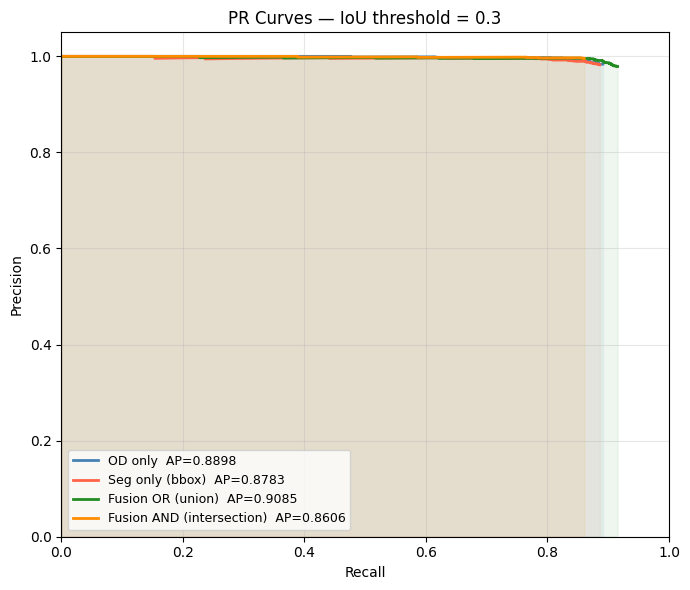

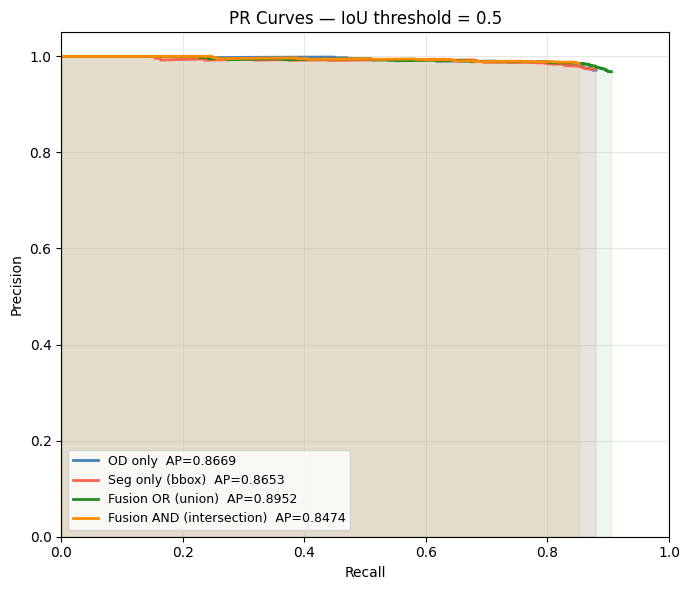

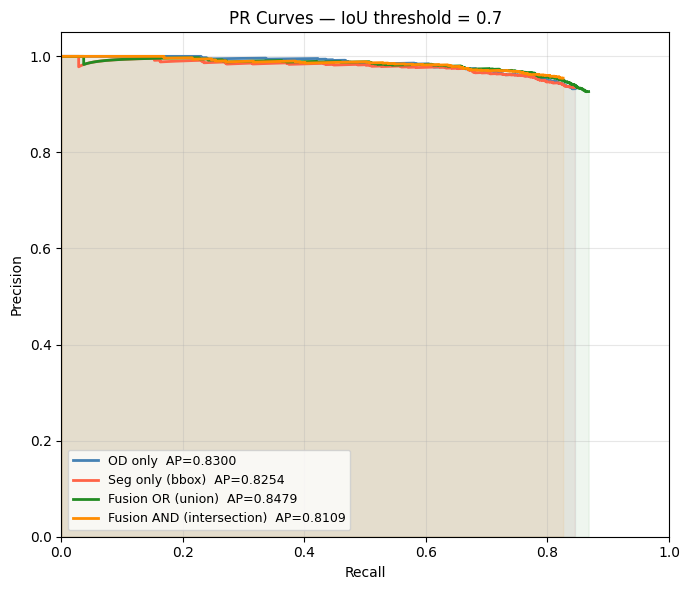

In [89]:
colors = {'od_only': 'steelblue', 'seg_only': 'tomato',
          'or': 'forestgreen', 'and': 'darkorange'}

for iou_threshold in iou_thresholds_report:
    fig, ax = plt.subplots(figsize=(7, 6))
    for strategy in strategies:
        ndf = results_by_strategy_iou[strategy][iou_threshold]
        ap, recalls, precisions = calculate_ap(ndf)
        if len(recalls) == 0:
            continue
        label = f"{strategy_labels[strategy]}  AP={ap:.4f}"
        ax.plot(recalls, precisions, color=colors[strategy], linewidth=2, label=label)
        ax.fill_between(recalls, precisions, alpha=0.07, color=colors[strategy])

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curves — IoU threshold = {iou_threshold}')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [90]:
def visualize_ensemble_samples(od_raw, seg_raw, results_by_strategy_iou,
                                od_root, strategy='or', iou_threshold=0.5,
                                n=16, mode='random', seed=42):
    """
    每張圖並排顯示 OD-only / Seg-only / Fused 結果。
    mode: 'random' | 'fp' | 'fn' | 'worst'
    """
    ndf_fused = results_by_strategy_iou[strategy][iou_threshold]
    grouped   = ndf_fused.groupby('file_name')

    if mode == 'random':
        rng = random.Random(seed)
        file_names = rng.sample(list(grouped.groups.keys()), min(n, len(grouped)))
    else:
        counts = (
            ndf_fused[ndf_fused['match_type'].isin(['FP', 'FN'])]
            .groupby(['file_name', 'match_type']).size().unstack(fill_value=0)
        )
        for col in ['FP', 'FN']:
            if col not in counts:
                counts[col] = 0
        if mode == 'fp':
            file_names = counts['FP'].nlargest(n).index.tolist()
        elif mode == 'fn':
            file_names = counts['FN'].nlargest(n).index.tolist()
        else:
            file_names = (counts['FP'] + counts['FN']).nlargest(n).index.tolist()

    # Build filename -> index map
    fname_to_idx = {Path(p).name: i for i, (p, _, _) in enumerate(od_raw)}

    color_map = {'TP_pred': 'lime', 'TP_gt': 'green',
                 'FP_pred': 'red',  'FN_gt': 'orange'}

    def draw_recs(ax, records):
        for rec in records:
            mt = rec['match_type']
            if mt == 'TP':
                for box, c, ls in [(rec['pred_box'], 'lime', '-'),
                                   (rec['gt_box'],   'green', '--')]:
                    if box:
                        ax.add_patch(mpatches.FancyBboxPatch(
                            (0, 0), 1, 1, visible=False))
                        ax.add_patch(plt.Rectangle(
                            (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                            linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
                if rec['pred_box']:
                    ax.text(rec['pred_box'][0], rec['pred_box'][1]-4,
                            f"TP iou={rec['iou']:.2f}", color='lime', fontsize=6)
            elif mt == 'FP':
                b = rec['pred_box']
                if b:
                    ax.add_patch(plt.Rectangle(
                        (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                        linewidth=2, edgecolor='red', facecolor='none'))
                    ax.text(b[0], b[1]-4, 'FP', color='red', fontsize=6)
            elif mt == 'FN':
                b = rec['gt_box']
                if b:
                    ax.add_patch(plt.Rectangle(
                        (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                        linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'))
                    ax.text(b[0], b[1]-4, 'FN', color='orange', fontsize=6)

    strategy_cols = ['od_only', 'seg_only', strategy]
    col_titles    = ['OD only', 'Seg only', f'Fusion ({strategy})']
    ncols, nrows  = len(strategy_cols), len(file_names)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for row_i, fname in enumerate(file_names):
        idx = fname_to_idx.get(fname)
        if idx is None:
            continue
        od_path = od_raw[idx][0]
        img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)

        for col_i, strat in enumerate(strategy_cols):
            ax = axes[row_i, col_i]
            ax.imshow(img)
            recs_df = results_by_strategy_iou[strat][iou_threshold]
            if fname in recs_df['file_name'].values:
                draw_recs(ax, recs_df[recs_df['file_name'] == fname].to_dict('records'))
            tp = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'TP').sum()
            fp = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'FP').sum()
            fn = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'FN').sum()
            ax.set_title(f"{col_titles[col_i]}\n{fname}\nTP={tp} FP={fp} FN={fn}",
                         fontsize=8)
            ax.axis('off')

    legend_elems = [
        mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP gt'),
        mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
        mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(f"Ensemble comparison  |  IoU={iou_threshold}  |  mode={mode}", fontsize=13)
    plt.tight_layout()
    plt.show()

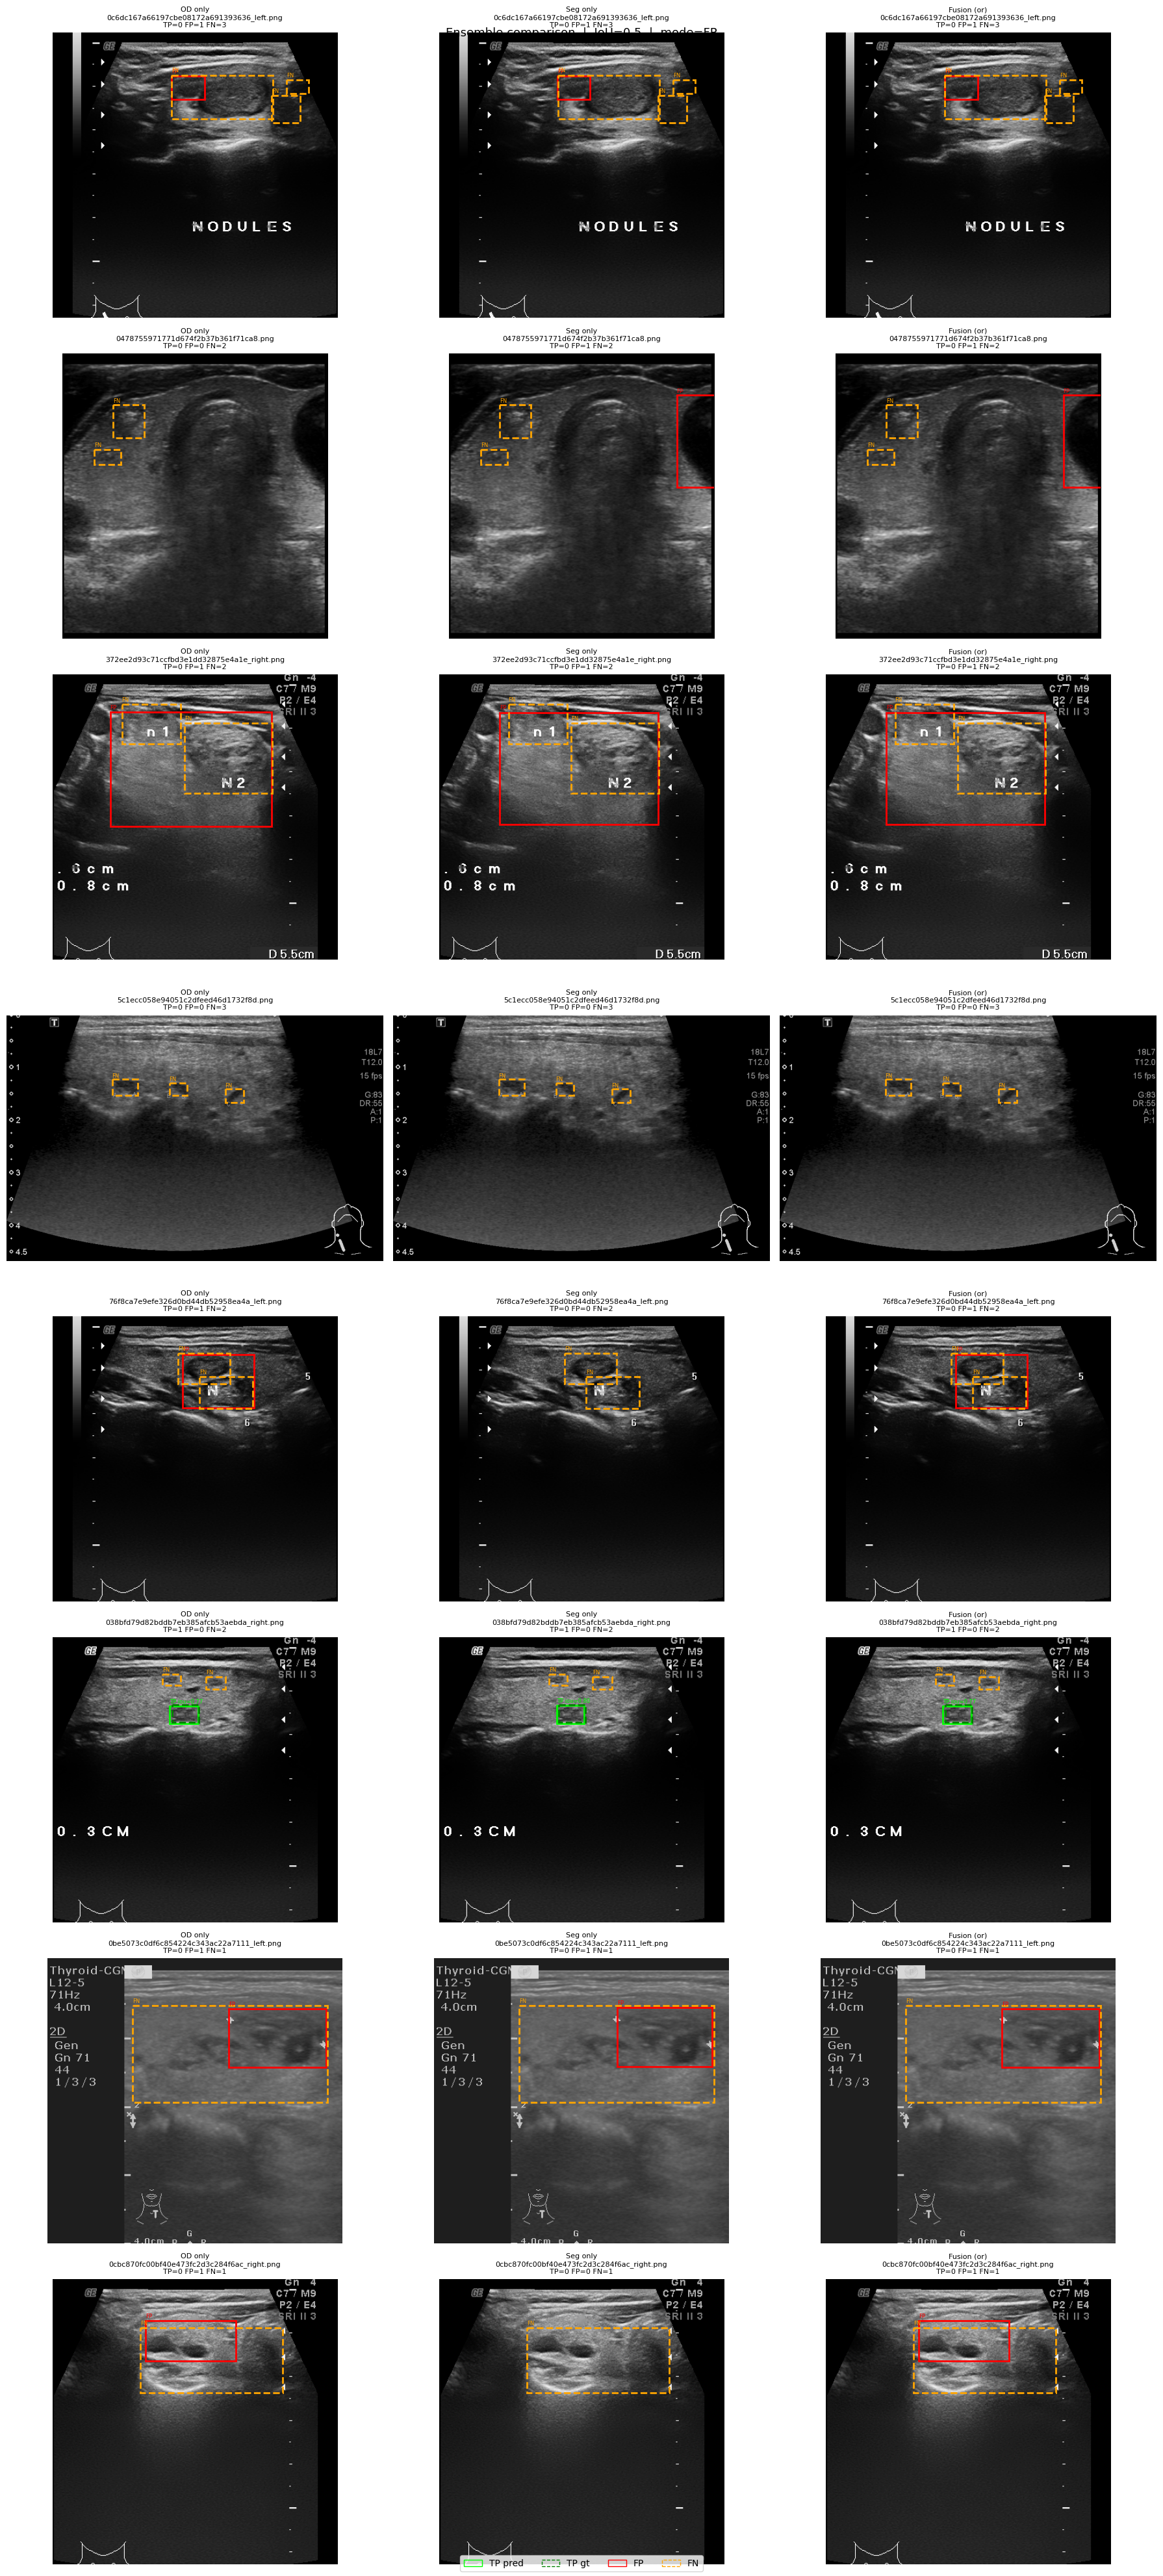

In [91]:
# 調整 mode: 'random' | 'fp' | 'fn' | 'worst'
# 調整 strategy: 'or' | 'and'

visualize_ensemble_samples(
    od_raw, seg_raw, results_by_strategy_iou,
    od_root=od_root,
    strategy='or',
    iou_threshold=0.5,
    n=8,
    mode='FP',
)

## 結節大小對效能之影響（定性分析）

以 GT bounding box 面積將結節分為 **小 / 中 / 大** 三類（依三分位數切割），
分析各策略在不同大小結節上的 Recall、Precision、F1 表現。

In [92]:
# ============================================================
# 結節大小分類設定（以 Fusion OR, IoU=0.5 的 GT boxes 為基準）
# ============================================================

SIZE_ANALYSIS_IOU = 0.5   # 分析用的 IoU 閾值

def get_gt_area(box):
    """計算 GT bbox 面積 (px²)"""
    if box is None:
        return None
    x1, y1, x2, y2 = box
    return max(0, x2 - x1) * max(0, y2 - y1)

def get_box_side(box):
    """計算 bbox 短邊長度 (px)"""
    if box is None:
        return None
    x1, y1, x2, y2 = box
    return min(x2 - x1, y2 - y1)

# 以 OR 策略的 TP+FN GT boxes 估計整體面積分佈
ref_df = results_by_strategy_iou['or'][SIZE_ANALYSIS_IOU]
ref_gt = ref_df[ref_df['match_type'].isin(['TP', 'FN'])].copy()
ref_gt['gt_area'] = ref_gt['gt_box'].apply(get_gt_area)
ref_areas = ref_gt['gt_area'].dropna()

q33 = np.percentile(ref_areas, 33)
q67 = np.percentile(ref_areas, 67)

SIZE_LABELS = [
    f'Small\n(<{q33:.0f} px²)',
    f'Medium\n({q33:.0f}–{q67:.0f} px²)',
    f'Large\n(≥{q67:.0f} px²)',
]

def size_category(area):
    if area is None or np.isnan(area):
        return None
    if area < q33:
        return SIZE_LABELS[0]
    elif area < q67:
        return SIZE_LABELS[1]
    else:
        return SIZE_LABELS[2]

print("GT 結節面積分佈（Fusion OR, IoU=0.5）")
print(f"  Min    : {ref_areas.min():.0f} px²")
print(f"  33%ile : {q33:.0f} px²  ← 小/中 分界")
print(f"  Median : {ref_areas.median():.0f} px²")
print(f"  67%ile : {q67:.0f} px²  ← 中/大 分界")
print(f"  Max    : {ref_areas.max():.0f} px²")
print(f"  N (GT) : {len(ref_areas)}")

GT 結節面積分佈（Fusion OR, IoU=0.5）
  Min    : 231 px²
  33%ile : 2680 px²  ← 小/中 分界
  Median : 5002 px²
  67%ile : 9409 px²  ← 中/大 分界
  Max    : 329175 px²
  N (GT) : 1573


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/668329044.py:37: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/668329044.py:37: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/668329044.py:37: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/668329044.py:37: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/668329044.py:37: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5

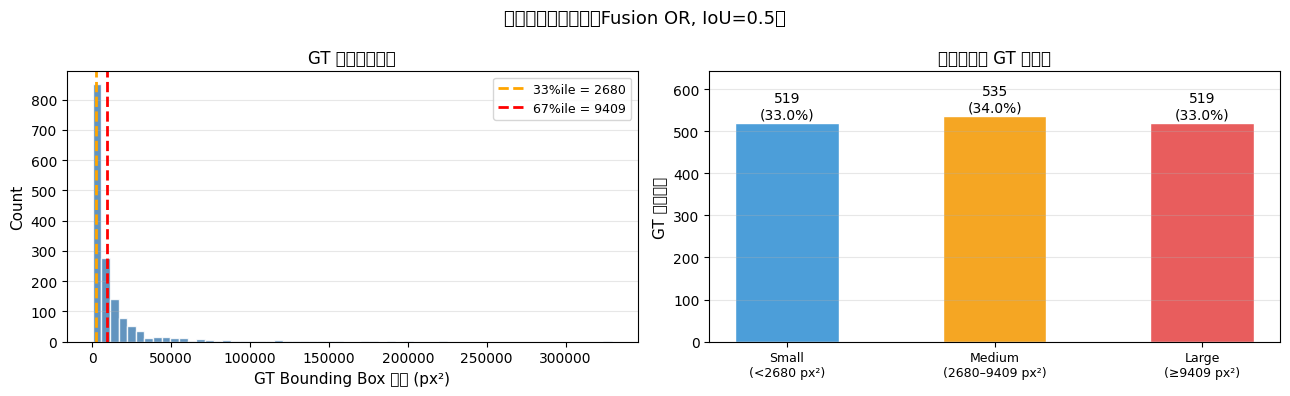

In [93]:
# ============================================================
# 結節面積分佈直方圖 + 大小分組佔比
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- 左：面積直方圖 ---
ax = axes[0]
ax.hist(ref_areas, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(q33, color='orange', linewidth=2, linestyle='--', label=f'33%ile = {q33:.0f}')
ax.axvline(q67, color='red',    linewidth=2, linestyle='--', label=f'67%ile = {q67:.0f}')
ax.set_xlabel('GT Bounding Box 面積 (px²)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('GT 結節面積分佈', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- 右：各大小分組 GT 數量 ---
ref_gt['size_cat'] = ref_gt['gt_area'].apply(size_category)
cat_counts = ref_gt['size_cat'].value_counts().reindex(SIZE_LABELS).fillna(0)

ax2 = axes[1]
bars = ax2.bar(range(len(SIZE_LABELS)), cat_counts.values,
               color=['#4C9ED9', '#F5A623', '#E85D5D'], edgecolor='white', width=0.5)
for bar, val in zip(bars, cat_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{int(val)}\n({int(val)/len(ref_gt)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)
ax2.set_xticks(range(len(SIZE_LABELS)))
ax2.set_xticklabels(SIZE_LABELS, fontsize=9)
ax2.set_ylabel('GT 結節數量', fontsize=11)
ax2.set_title('各大小分組 GT 結節數', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, cat_counts.max() * 1.2)

plt.suptitle('結節大小分佈概覽（Fusion OR, IoU=0.5）', fontsize=13)
plt.tight_layout()
plt.show()

In [94]:
# ============================================================
# 各策略 × 結節大小 → TP/FP/FN 計數 & 指標
# ============================================================

size_records = []

for strategy in strategies:
    df = results_by_strategy_iou[strategy][SIZE_ANALYSIS_IOU].copy()

    # TP / FN → 以 GT box 面積分類
    df['gt_area'] = df['gt_box'].apply(get_gt_area)
    # FP → 以 pred box 面積代替（GT 不存在）
    fp_mask = df['match_type'] == 'FP'
    df.loc[fp_mask, 'gt_area'] = df.loc[fp_mask, 'pred_box'].apply(get_gt_area)

    df['size_cat'] = df['gt_area'].apply(size_category)
    df = df.dropna(subset=['size_cat'])

    for sc in SIZE_LABELS:
        sub = df[df['size_cat'] == sc]
        tp = (sub['match_type'] == 'TP').sum()
        fp = (sub['match_type'] == 'FP').sum()
        fn = (sub['match_type'] == 'FN').sum()
        recall, precision, f1 = compute_metrics_from_counts(tp, fp, fn)
        # TP 的平均 IoU
        tp_iou = sub.loc[sub['match_type'] == 'TP', 'iou'].dropna()
        size_records.append({
            'strategy':   strategy,
            'label':      strategy_labels[strategy],
            'size_cat':   sc,
            'TP': tp, 'FP': fp, 'FN': fn,
            'recall':     recall,
            'precision':  precision,
            'f1':         f1,
            'mean_iou':   tp_iou.mean() if len(tp_iou) else np.nan,
        })

size_df = pd.DataFrame(size_records)

# 顯示數字表格
pivot_f1 = size_df.pivot_table(index='label', columns='size_cat',
                                values='f1', aggfunc='first')[SIZE_LABELS]
pivot_recall = size_df.pivot_table(index='label', columns='size_cat',
                                    values='recall', aggfunc='first')[SIZE_LABELS]
pivot_prec = size_df.pivot_table(index='label', columns='size_cat',
                                  values='precision', aggfunc='first')[SIZE_LABELS]

print("=== F1 by Size Category (IoU=0.5) ===")
display(pivot_f1.round(4))
print("\n=== Recall by Size Category ===")
display(pivot_recall.round(4))
print("\n=== Precision by Size Category ===")
display(pivot_prec.round(4))

=== F1 by Size Category (IoU=0.5) ===


size_cat,Small\n(<2680 px²),Medium\n(2680–9409 px²),Large\n(≥9409 px²)
label,,,
Fusion AND (intersection),0.9110,0.9087,0.9215
Fusion OR (union),0.9374,0.9243,0.9451
OD only,0.9204,0.9167,0.9328
Seg only (bbox),0.9270,0.9082,0.9343



=== Recall by Size Category ===


size_cat,Small\n(<2680 px²),Medium\n(2680–9409 px²),Large\n(≥9409 px²)
label,,,
Fusion AND (intersection),0.8478,0.8374,0.8709
Fusion OR (union),0.9094,0.8785,0.9287
OD only,0.8805,0.8636,0.8960
Seg only (bbox),0.8805,0.8505,0.9037



=== Precision by Size Category ===


size_cat,Small\n(<2680 px²),Medium\n(2680–9409 px²),Large\n(≥9409 px²)
label,,,
Fusion AND (intersection),0.9843,0.9933,0.9784
Fusion OR (union),0.9672,0.9751,0.9621
OD only,0.9641,0.9767,0.9728
Seg only (bbox),0.9786,0.9743,0.9670


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/107853907.py:37: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/107853907.py:37: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/107853907.py:37: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/107853907.py:37: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/107853907.py:37: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5

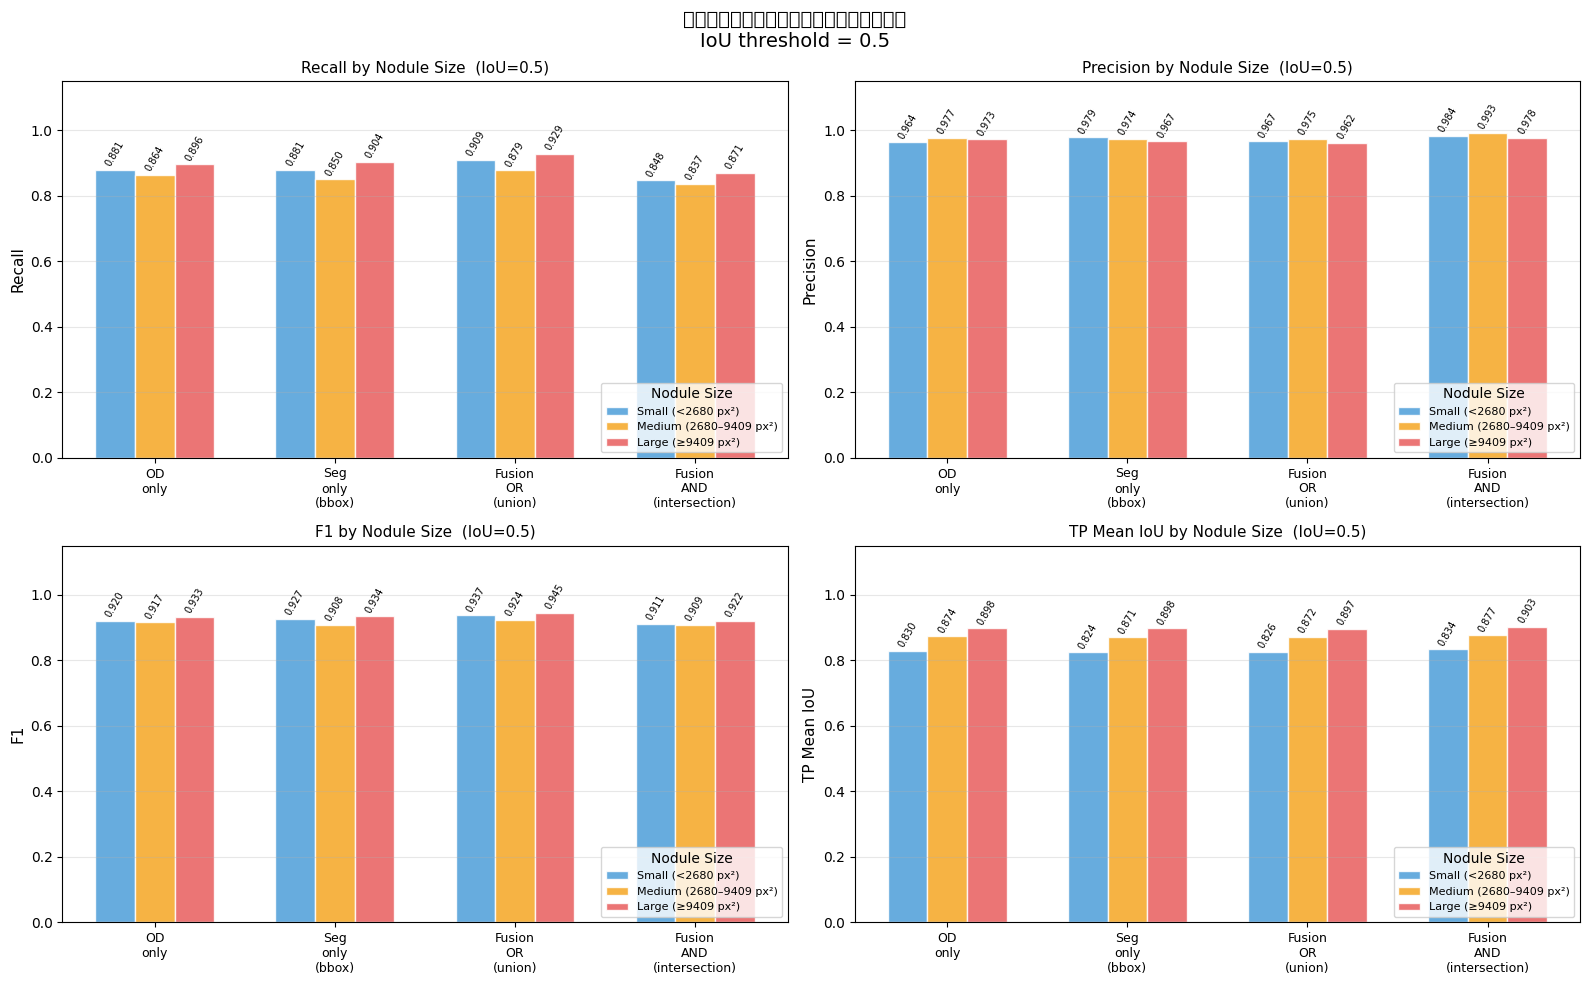

In [95]:
# ============================================================
# 視覺化：各策略 × 大小分組 的 Recall / Precision / F1 / TP-IoU
# ============================================================

metrics_to_plot = ['recall', 'precision', 'f1', 'mean_iou']
metric_titles   = ['Recall', 'Precision', 'F1', 'TP Mean IoU']
size_colors     = ['#4C9ED9', '#F5A623', '#E85D5D']   # small / medium / large

x      = np.arange(len(strategies))
width  = 0.22

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metric, title in zip(axes.flat, metrics_to_plot, metric_titles):
    for si, sc in enumerate(SIZE_LABELS):
        vals = []
        for strategy in strategies:
            row = size_df[(size_df['strategy'] == strategy) & (size_df['size_cat'] == sc)]
            vals.append(float(row[metric].values[0]) if len(row) > 0 else 0)
        offset = (si - 1) * width
        bars = ax.bar(x + offset, vals, width, label=sc.replace('\n', ' '),
                      color=size_colors[si], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=60)

    ax.set_xticks(x)
    ax.set_xticklabels([strategy_labels[s].replace(' ', '\n') for s in strategies], fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} by Nodule Size  (IoU={SIZE_ANALYSIS_IOU})', fontsize=11)
    ax.legend(title='Nodule Size', fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('結節大小對各策略效能之影響（定性分析）\nIoU threshold = 0.5', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1849561913.py:36: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1849561913.py:36: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1849561913.py:36: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1849561913.py:36: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1849561913.py:36: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

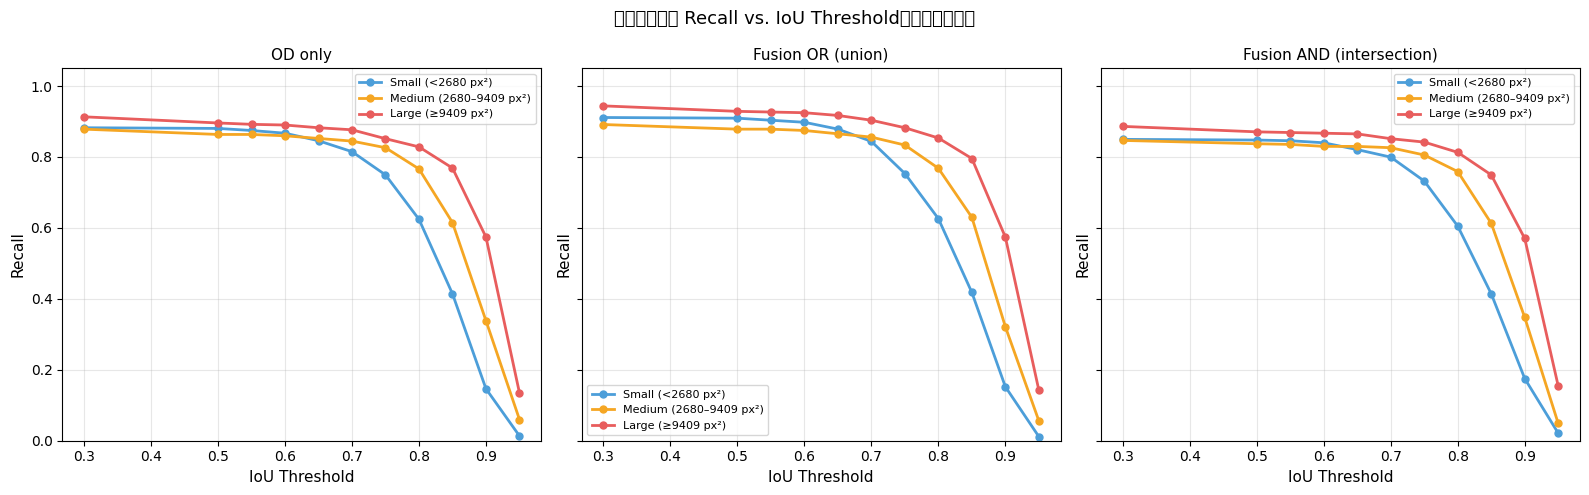

In [96]:
# ============================================================
# 跨 IoU 閾值分析：各大小類別的 Recall 趨勢（以 OR 策略為例）
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
iou_sweep = iou_thresholds_report   # [0.3, 0.5, 0.7]

# 改用連續的 IoU 值呈現趨勢
iou_sweep_full = all_iou_thresholds   # 全部評估過的閾值

for ax, strategy in zip(axes, ['od_only', 'or', 'and']):
    for si, sc in enumerate(SIZE_LABELS):
        recalls = []
        for iou_thr_val in iou_sweep_full:
            df_iou = results_by_strategy_iou[strategy][iou_thr_val].copy()
            df_iou['gt_area'] = df_iou['gt_box'].apply(get_gt_area)
            fp_m = df_iou['match_type'] == 'FP'
            df_iou.loc[fp_m, 'gt_area'] = df_iou.loc[fp_m, 'pred_box'].apply(get_gt_area)
            df_iou['size_cat'] = df_iou['gt_area'].apply(size_category)
            sub = df_iou[df_iou['size_cat'] == sc]
            tp = (sub['match_type'] == 'TP').sum()
            fn = (sub['match_type'] == 'FN').sum()
            recall, _, _ = compute_metrics_from_counts(tp, 0, fn)
            recalls.append(recall)
        ax.plot(iou_sweep_full, recalls, marker='o', markersize=5,
                color=size_colors[si], linewidth=2,
                label=sc.replace('\n', ' '))
    ax.set_xlabel('IoU Threshold', fontsize=11)
    ax.set_ylabel('Recall', fontsize=11)
    ax.set_title(f'{strategy_labels[strategy]}', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('各結節大小的 Recall vs. IoU Threshold（跨策略比較）', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/427290643.py:87: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/427290643.py:87: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/427290643.py:87: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/427290643.py:87: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/427290643.py:87: UserWarning: Glyph 27171 (\N{CJK UNIFIED IDEOGRAPH-6A23}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5

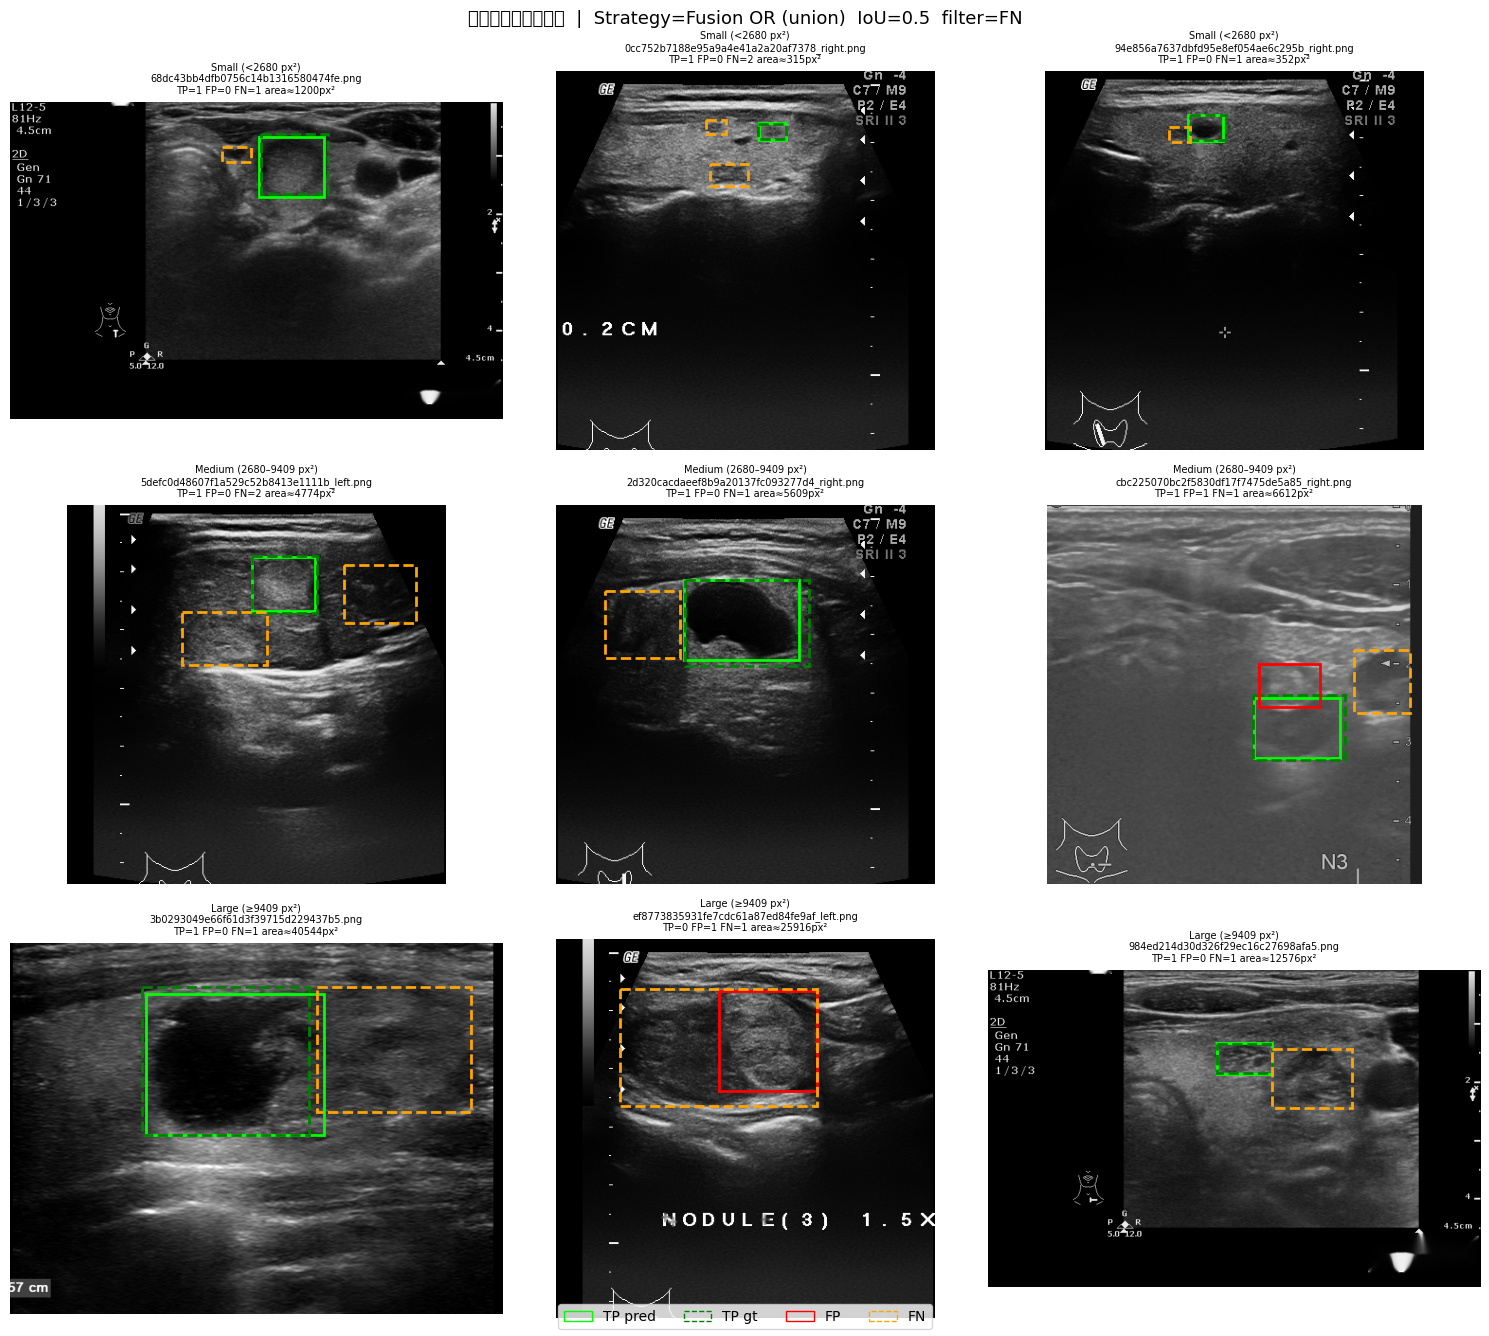

In [97]:
# ============================================================
# 樣本視覺化：每個大小分組各取 N 個 FN（漏偵）和 TP 案例
# ============================================================

def visualize_by_size(od_raw, seg_raw, results_by_strategy_iou,
                      strategy='or', iou_threshold=0.5,
                      n_per_cat=3, match_type_filter='FN', seed=42):
    """
    按結節大小分組，從指定 match_type（FN 或 TP）中各抽樣 n_per_cat 張圖顯示。
    """
    rng = random.Random(seed)
    df = results_by_strategy_iou[strategy][iou_threshold].copy()
    df['gt_area']  = df['gt_box'].apply(get_gt_area)
    fp_m = df['match_type'] == 'FP'
    df.loc[fp_m, 'gt_area'] = df.loc[fp_m, 'pred_box'].apply(get_gt_area)
    df['size_cat'] = df['gt_area'].apply(size_category)

    fname_to_idx = {Path(p).name: i for i, (p, _, _) in enumerate(od_raw)}

    nrows = len(SIZE_LABELS)
    ncols = n_per_cat
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for row_i, sc in enumerate(SIZE_LABELS):
        sub = df[(df['size_cat'] == sc) & (df['match_type'] == match_type_filter)]
        fnames = sub['file_name'].unique().tolist()
        fnames = rng.sample(fnames, min(n_per_cat, len(fnames)))

        for col_i in range(ncols):
            ax = axes[row_i, col_i]
            ax.axis('off')
            if col_i >= len(fnames):
                continue
            fname = fnames[col_i]
            idx = fname_to_idx.get(fname)
            if idx is None:
                continue
            od_path = od_raw[idx][0]
            img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)
            ax.imshow(img)

            recs = df[df['file_name'] == fname].to_dict('records')
            for rec in recs:
                mt = rec['match_type']
                if mt == 'TP':
                    for box, c, ls in [(rec['pred_box'], 'lime', '-'),
                                       (rec['gt_box'],   'green', '--')]:
                        if box:
                            ax.add_patch(plt.Rectangle(
                                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
                elif mt == 'FP':
                    b = rec['pred_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='red', facecolor='none'))
                elif mt == 'FN':
                    b = rec['gt_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'))

            tp = sum(1 for r in recs if r['match_type'] == 'TP')
            fp = sum(1 for r in recs if r['match_type'] == 'FP')
            fn = sum(1 for r in recs if r['match_type'] == 'FN')
            area_val = sub[sub['file_name'] == fname]['gt_area'].values
            area_str = f"{area_val[0]:.0f}px²" if len(area_val) > 0 else ''
            ax.set_title(f"{sc.replace(chr(10), ' ')}\n{fname}\nTP={tp} FP={fp} FN={fn} area≈{area_str}",
                         fontsize=7)

    legend_elems = [
        mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP gt'),
        mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
        mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(
        f'結節大小樣本視覺化  |  Strategy={strategy_labels[strategy]}  '
        f'IoU={iou_threshold}  filter={match_type_filter}',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

# FN（漏偵）樣本：最能體現小結節偵測困難
visualize_by_size(od_raw, seg_raw, results_by_strategy_iou,
                  strategy='or', iou_threshold=0.5,
                  n_per_cat=3, match_type_filter='FN')